<div style="background-color:#d5f5e3; padding:20px; border-left:8px solid #27AE60; border-radius:8px; color:#1b1b1b;">

## **Proyecto final de aprendizaje automático**

**Bootcamp:** 4Geeks Academy – Intro to Machine Learning  
**Autores:** Anais Aponte, Balam Castro, Cristina Cerverón 

</div>

In [1]:
# ============================================================
# IMPORTACIÓN DE LIBRERÍAS
# ============================================================

# Manipulación y análisis de datos
import numpy as np
import pandas as pd

# Trabajo geoespacial
import geopandas as gpd

# Visualización de datos
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# ============================================================
# CARGA DEL DATASET
# ============================================================

# Cargamos el dataset final procesado generado en el notebook 01_build_dataset.ipynb.
df_bcn = pd.read_csv('../data/processed/dataset_final.csv')

In [3]:
# ============================================================
# PRIMERA VISUALIZACIÓN DEL DATASET
# ============================================================

# Mostramos una muestra aleatoria de registros para revisar rápidamente la estructura general del dataset.

df_bcn.sample(10)

,system:index_x,blue,bsi,fecha,green,latitude_x,longitude_x,mndwi,month_x,nbr,...,system:index_y,latitude_y,longitude_y,lst_day_c,lst_night_c,month_y,occurrence_y,year_y,.geo_y,elevation
68289,1_854_0_0,0.06580,0.034119,2022-08-01,0.08090,41.384801,2.191126,-0.352282,8.0,0.126392,...,1_854_0_0,41.384801,2.191126,33.300000,24.035000,8.0,0,2022,"{""type"":""MultiPoint"",""coordinates"":[]}",1
27618,1_878_0_0,0.06470,0.035228,2020-05-01,0.09660,41.461607,2.101115,-0.427895,5.0,0.214884,...,1_878_0_0,41.461607,2.101115,27.270000,15.863333,5.0,0,2020,"{""type"":""MultiPoint"",""coordinates"":[]}",170
5560,2_823_0_0,0.13210,0.140778,2021-09-01,0.16810,41.443282,2.215650,-0.261099,9.0,-0.058674,...,2_823_0_0,41.443282,2.215650,29.235000,19.445000,9.0,0,2021,"{""type"":""MultiPoint"",""coordinates"":[]}",66
15123,0_249_0_0,0.00885,-0.174427,2021-01-01,0.01025,41.404474,2.111086,-0.674086,1.0,0.441639,...,0_249_0_0,41.404474,2.111086,10.205000,6.150000,1.0,0,2021,"{""type"":""MultiPoint"",""coordinates"":[]}",202
26028,2_152_0_0,0.02510,-0.325628,2021-12-01,0.04500,41.347611,2.057995,-0.537750,12.0,0.607843,...,2_152_0_0,41.347611,2.057995,12.610000,7.635000,12.0,0,2021,"{""type"":""MultiPoint"",""coordinates"":[]}",4
27407,1_581_0_0,0.17260,-0.021277,2020-05-01,0.17780,41.349228,2.117554,-0.105184,5.0,0.138302,...,1_581_0_0,41.349228,2.117554,33.230000,18.996667,5.0,0,2020,"{""type"":""MultiPoint"",""coordinates"":[]}",11
62792,2_126_0_0,0.04340,0.020013,2023-06-01,0.06820,41.483436,2.179268,-0.552200,6.0,0.182247,...,2_126_0_0,41.483436,2.179268,34.585000,21.730000,6.0,0,2023,"{""type"":""MultiPoint"",""coordinates"":[]}",52
41713,1_1347_0_0,0.04810,0.181987,2024-11-01,0.07030,41.403127,2.131028,-0.486580,11.0,-0.042900,...,1_1347_0_0,41.403127,2.131028,16.923333,12.916667,11.0,0,2024,"{""type"":""MultiPoint"",""coordinates"":[]}",132
63158,2_657_0_0,0.09260,0.121144,2023-06-01,0.11740,41.374021,2.046946,-0.398874,6.0,-0.038328,...,2_657_0_0,41.374021,2.046946,37.880000,23.190000,6.0,0,2023,"{""type"":""MultiPoint"",""coordinates"":[]}",18
29613,0_879_0_0,0.04040,0.232659,2020-01-01,0.06010,41.490174,2.054492,-0.635647,1.0,-0.060366,...,0_879_0_0,41.490174,2.054492,12.020000,3.655000,1.0,0,2020,"{""type"":""MultiPoint"",""coordinates"":[]}",170


In [4]:
# ============================================================
# REVISIÓN DE COLUMNAS
# ============================================================

# Mostramos todas las columnas completas del dataset.
df_bcn.columns

Index(['system:index_x', 'blue', 'bsi', 'fecha', 'green', 'latitude_x',
       'longitude_x', 'mndwi', 'month_x', 'nbr', 'ndbi', 'ndmi', 'ndvi',
       'ndwi', 'nir', 'occurrence_x', 'point_id', 'red', 'savi', 'swir1',
       'swir2', 'year_x', '.geo_x', 'system:index_y', 'latitude_y',
       'longitude_y', 'lst_day_c', 'lst_night_c', 'month_y', 'occurrence_y',
       'year_y', '.geo_y', 'elevation'],
      dtype='str')

In [5]:
# ============================================================
# LIMPIEZA DE COLUMNAS
# ============================================================

# Eliminamos columnas técnicas y duplicadas tras el merge.
cols_drop = [
    'system:index_x', 'system:index_y',
    '.geo_x', '.geo_y',
    'occurrence_x', 'occurrence_y',
    'latitude_y', 'longitude_y',
    'month_y', 'year_y',
    'red', 'green', 'blue'
]

df_bcn = df_bcn.drop(
    columns=[c for c in cols_drop if c in df_bcn.columns]
)

In [6]:
# ============================================================
# RENOMBRE DE COLUMNAS
# ============================================================

# Renombramos columnas para dejar nombres más limpios y consistentes.
df_bcn = df_bcn.rename(columns={
    'latitude_x': 'latitude',
    'longitude_x': 'longitude',
    'month_x': 'month',
    'year_x': 'year'
})

In [7]:
# ============================================================
# FORMATO DE FECHA
# ============================================================

# Renombramos la columna fecha y la convertimos a datetime.

df_bcn = df_bcn.rename(columns={'fecha': 'date'})

df_bcn['date'] = pd.to_datetime(df_bcn['date'])

In [8]:
# ============================================================
# REORDENAR COLUMNAS
# ============================================================

# Reordenamos columnas principales para facilitar la lectura del dataset.

cols_first = [
    'point_id',
    'date',
    'latitude',
    'longitude',
    'elevation',
    'month',
    'year'
]

cols_first = [c for c in cols_first if c in df_bcn.columns]

cols_rest = [c for c in df_bcn.columns if c not in cols_first]

df_bcn = df_bcn[cols_first + cols_rest]

# Visualizamos las primeras filas tras reorganizar las columnas.
df_bcn.head(20)

,point_id,date,latitude,longitude,elevation,month,year,bsi,mndwi,nbr,ndbi,ndmi,ndvi,ndwi,nir,savi,swir1,swir2,lst_day_c,lst_night_c
0,0.0,2020-10-01,41.438161,2.099767,301,10.0,2020,-0.312553,-0.542042,0.674365,-0.358526,0.358526,0.838158,-0.754032,0.2175,1.256971,0.10270,0.04230,18.125,10.965
1,1.0,2020-10-01,41.455948,2.191665,27,10.0,2020,0.106304,-0.317261,0.018942,0.069360,-0.069360,0.212814,-0.253480,0.2972,0.319188,0.34150,0.28615,20.825,12.565
2,2.0,2020-10-01,41.376447,2.102462,85,10.0,2020,0.061652,-0.350239,0.054307,0.005074,-0.005074,0.299576,-0.345779,0.2451,0.449304,0.24760,0.21985,21.685,12.930
3,3.0,2020-10-01,41.396659,2.139652,92,10.0,2020,0.084935,-0.121158,-0.036384,0.116056,-0.116056,0.017166,-0.005175,0.0874,0.025742,0.11035,0.09400,21.835,14.425
4,4.0,2020-10-01,41.368093,2.043173,15,10.0,2020,0.061221,-0.362908,0.189122,-0.056646,0.056646,0.300055,-0.411103,0.2383,0.450020,0.21275,0.16250,23.155,11.635
5,5.0,2020-10-01,41.433580,2.211607,14,10.0,2020,-0.078147,-0.167432,0.427252,-0.214827,0.214827,0.340356,-0.368987,0.2163,0.510455,0.13980,0.08680,23.280,13.440
6,6.0,2020-10-01,41.466458,2.190048,31,10.0,2020,0.112656,-0.475092,0.106182,0.082434,-0.082434,0.305866,-0.408663,0.1870,0.458719,0.22060,0.15110,21.670,11.330
7,7.0,2020-10-01,41.452983,2.194629,34,10.0,2020,-0.087722,-0.467693,0.371750,-0.151288,0.151288,0.611043,-0.578078,0.3297,0.916453,0.24305,0.15100,22.770,12.430
8,8.0,2020-10-01,41.492060,2.187353,40,10.0,2020,-0.076923,-0.453865,0.279702,-0.157311,0.157311,0.573534,-0.570448,0.2402,0.860160,0.17490,0.13520,23.340,11.030
9,9.0,2020-10-01,41.449480,2.180346,115,10.0,2020,0.042597,-0.409813,0.199557,-0.034279,0.034279,0.367331,-0.437940,0.2708,0.550928,0.25285,0.18070,20.090,12.205


In [9]:
# ============================================================
# INFORMACIÓN GENERAL DEL DATASET
# ============================================================

# Revisamos tipos de datos, valores nulos y memoria utilizada.

df_bcn.info()

<class 'pandas.DataFrame'>
RangeIndex: 69683 entries, 0 to 69682
Data columns (total 20 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   point_id     69683 non-null  float64       
 1   date         69683 non-null  datetime64[us]
 2   latitude     69683 non-null  float64       
 3   longitude    69683 non-null  float64       
 4   elevation    69683 non-null  int64         
 5   month        69683 non-null  float64       
 6   year         69683 non-null  int64         
 7   bsi          69683 non-null  float64       
 8   mndwi        69683 non-null  float64       
 9   nbr          69683 non-null  float64       
 10  ndbi         69683 non-null  float64       
 11  ndmi         69683 non-null  float64       
 12  ndvi         69683 non-null  float64       
 13  ndwi         69683 non-null  float64       
 14  nir          69683 non-null  float64       
 15  savi         69683 non-null  float64       
 16  swir1        69

In [10]:
# ============================================================
# DIMENSIONES DEL DATASET
# ============================================================

# Revisamos el número de filas y columnas del dataset.

df_bcn.shape

(69683, 20)

<div style="background-color:#fff3cd; padding:20px; border-left:8px solid #ffcc00; border-radius:8px; color:#1b1b1b;">

### **Observación**

El dataset actual contiene la información base obtenida tras el merge entre Sentinel-2 y MODIS, con variables espaciales, temporales y espectrales suficientes. Sin embargo, para enriquecer el análisis y preparar mejor los datos para el modelado de riesgo UHI, se crearán nuevas variables derivadas y variables categóricas que aporten contexto climático y temporal adicional, como anomalías térmicas, amplitud térmica, estaciones del año y variables temporales derivadas de la fecha.



</div>

In [11]:
# ============================================================
# ANOMALÍA TÉRMICA DIURNA
# ============================================================

# Calculamos cuánto se desvía la temperatura diurna respecto a la media del mismo mes.
# Valores positivos indican zonas más calientes de lo normal.

df_bcn['lst_day_anomaly'] = (
    df_bcn['lst_day_c'] -
    df_bcn.groupby('month')['lst_day_c'].transform('mean')
)

In [12]:
# ============================================================
# ANOMALÍA TÉRMICA NOCTURNA
# ============================================================

# Calculamos cuánto se desvía la temperatura nocturna respecto a la media mensual.
# Esto es especialmente útil para detectar Urban Heat Islands, ya que las ciudades suelen mantenerse más calientes por la noche.

df_bcn['lst_night_anomaly'] = (
    df_bcn['lst_night_c'] -
    df_bcn.groupby('month')['lst_night_c'].transform('mean')
)

In [13]:
# ============================================================
# AMPLITUD TÉRMICA
# ============================================================

# Calculamos la diferencia entre la temperatura diurna y nocturna.
# Esta variable ayuda a detectar zonas urbanas que retienen calor durante la noche, fenómeno típico de las Urban Heat Islands (UHI).

df_bcn['thermal_amplitude'] = (
    df_bcn['lst_day_c'] - df_bcn['lst_night_c']
)

In [14]:
# ============================================================
# SEASON
# ============================================================

# Creamos una variable categórica de estación del año a partir del mes.

def get_season(month):

    if month in [12, 1, 2]:
        return 'winter'

    elif month in [3, 4, 5]:
        return 'spring'

    elif month in [6, 7, 8]:
        return 'summer'

    else:
        return 'autumn'


df_bcn['season'] = df_bcn['month'].apply(get_season)

In [15]:
# ============================================================
# VARIABLE TARGET: UHI RISK
# ============================================================

# Creamos una variable objetivo binaria de riesgo UHI utilizando la anomalía térmica nocturna (lst_night_anomaly).
# Las Urban Heat Islands se estudian sobre todo por:
# - retención nocturna del calor
# - incapacidad de enfriamiento urbano durante la noche
#
# Se utiliza una clasificación binaria para:
#
# - simplificar el problema de clasificación,
# - facilitar la interpretación del modelo,
# - y mejorar la claridad en la evaluación del rendimiento predictivo.
#
# El umbral de riesgo se establece en la mediana de lst_night_anomaly:
#
# - 0 → no risk:  anomalía por debajo de la mediana
# - 1 → risk:     anomalía igual o por encima de la mediana
#
# Esto garantiza clases perfectamente balanceadas para el entrenamiento.

median_threshold = df_bcn['lst_night_anomaly'].median()

df_bcn['uhi_risk'] = (df_bcn['lst_night_anomaly'] >= 0).astype(int)

In [16]:
# ============================================================
# FINAL DATASET SHAPE
# ============================================================

# Verificamos el número de filas y columnas del dataset final.

df_bcn.shape

(69683, 25)

In [17]:
# ============================================================
# FINAL DATASET INFO
# ============================================================

# Revisamos tipos de datos, valores nulos y memoria utilizada del dataset final.

df_bcn.info()

<class 'pandas.DataFrame'>
RangeIndex: 69683 entries, 0 to 69682
Data columns (total 25 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   point_id           69683 non-null  float64       
 1   date               69683 non-null  datetime64[us]
 2   latitude           69683 non-null  float64       
 3   longitude          69683 non-null  float64       
 4   elevation          69683 non-null  int64         
 5   month              69683 non-null  float64       
 6   year               69683 non-null  int64         
 7   bsi                69683 non-null  float64       
 8   mndwi              69683 non-null  float64       
 9   nbr                69683 non-null  float64       
 10  ndbi               69683 non-null  float64       
 11  ndmi               69683 non-null  float64       
 12  ndvi               69683 non-null  float64       
 13  ndwi               69683 non-null  float64       
 14  nir              

In [18]:
# ============================================================
# FINAL DATASET PREVIEW
# ============================================================

# Mostramos una muestra aleatoria del dataset final tras el feature engineering.

df_bcn.sample(10)

,point_id,date,latitude,longitude,elevation,month,year,bsi,mndwi,nbr,...,savi,swir1,swir2,lst_day_c,lst_night_c,lst_day_anomaly,lst_night_anomaly,thermal_amplitude,season,uhi_risk
29923,927.0,2020-01-01,41.481550,2.131567,77,1.0,2020,0.230405,-0.488433,-0.214527,...,0.283797,0.17050,0.14380,11.160000,4.835000,-0.061689,-0.989563,6.325000,winter,0
69499,814.0,2022-09-01,41.305570,2.056109,3,9.0,2022,0.019958,-0.102947,0.074689,...,0.100405,0.43230,0.35680,31.110000,18.200000,3.732201,-0.153232,12.910000,autumn,0
61304,595.0,2023-04-01,41.492330,2.103270,143,4.0,2023,-0.001756,-0.468900,0.238368,...,0.739136,0.24560,0.17270,26.423333,10.930000,2.820964,-0.203891,15.493333,spring,0
25983,61.0,2021-12-01,41.497180,2.252570,289,12.0,2021,-0.310408,-0.461424,0.588616,...,1.290583,0.09850,0.04770,9.965000,6.715000,-1.740706,-0.455741,3.250000,winter,0
5731,747.0,2021-09-01,41.466189,2.038322,101,9.0,2021,0.065767,-0.453937,0.125858,...,0.686059,0.18465,0.13370,26.875000,17.195000,-0.502799,-1.158232,9.680000,autumn,0
31143,152.0,2020-03-01,41.366476,2.150971,90,3.0,2020,0.072872,-0.210879,0.104125,...,0.187760,0.28940,0.24650,21.255000,9.790000,2.247298,0.872993,11.465000,spring,1
43098,335.0,2021-04-01,41.436275,2.174956,66,4.0,2021,0.280722,-0.484050,-0.164724,...,0.033532,0.21400,0.18490,21.683333,8.390000,-1.919036,-2.743891,13.293333,spring,0
6076,94.0,2020-07-01,41.473195,2.140730,90,7.0,2020,-0.187889,-0.470116,0.495368,...,1.044822,0.24290,0.13890,31.075000,20.120000,-4.115262,-3.046219,10.955000,summer,0
45795,40.0,2023-10-01,41.460260,2.238018,67,10.0,2023,0.077755,-0.095561,0.087032,...,0.036444,0.20980,0.18410,23.370000,16.743333,1.683345,1.822936,6.626667,autumn,1
46723,971.0,2023-10-01,41.495833,2.280867,235,10.0,2023,-0.103050,-0.304080,0.351169,...,0.684302,0.15900,0.11035,22.590000,16.190000,0.903345,1.269603,6.400000,autumn,1


<div style="background-color:#fff3cd; padding:20px; border-left:8px solid #ffcc00; border-radius:8px; color:#1b1b1b;">

### 📚 Data Dictionary

A continuación se describen las variables que componen al dataset final:

| Variable | Tipo | Descripción |
|---|---|---|
| `point_id` | float64 | Identificador único del punto geográfico |
| `date` | datetime | Fecha de adquisición aproximada de los datos satelitales |
| `latitude` | float64 | Latitud del punto geográfico |
| `longitude` | float64 | Longitud del punto geográfico |
| `month` | float64 | Mes extraído de la fecha |
| `year` | int64 | Año extraído de la fecha |
| `blue` | float64 | Banda azul de Sentinel-2 |
| `green` | float64 | Banda verde de Sentinel-2 |
| `red` | float64 | Banda roja de Sentinel-2 |
| `nir` | float64 | Banda infrarroja cercana (Near Infrared) |
| `swir1` | float64 | Banda SWIR 1 de Sentinel-2 |
| `swir2` | float64 | Banda SWIR 2 de Sentinel-2 |
| `bsi` | float64 | Bare Soil Index |
| `mndwi` | float64 | Modified Normalized Difference Water Index |
| `nbr` | float64 | Normalized Burn Ratio |
| `ndbi` | float64 | Normalized Difference Built-up Index |
| `ndmi` | float64 | Normalized Difference Moisture Index |
| `ndvi` | float64 | Normalized Difference Vegetation Index |
| `ndwi` | float64 | Normalized Difference Water Index |
| `savi` | float64 | Soil Adjusted Vegetation Index |
| `lst_day_c` | float64 | Temperatura superficial diurna (°C) obtenida de MODIS |
| `lst_night_c` | float64 | Temperatura superficial nocturna (°C) obtenida de MODIS |
| `lst_day_anomaly` | float64 | Desviación térmica diurna respecto a la media mensual |
| `lst_night_anomaly` | float64 | Desviación térmica nocturna respecto a la media mensual |
| `thermal_amplitude` | float64 | Diferencia entre temperatura diurna y nocturna |
| `season` | object | Estación del año derivada del mes |
| `city` | object | Ciudad asociada al registro |
| `uhi_risk` | category | Variable objetivo categórica de riesgo UHI |

Este diccionario de datos facilitará la interpretación de las variables durante el análisis exploratorio y el modelado del riesgo de Urban Heat Island (UHI).

El dataset contiene un total de **6.9683 observaciones** y **27 variables**.

**No se detectan valores nulos en ninguna de las variables**, por lo que no es necesario realizar ningún tratamiento adicional en esta fase.

</div>

In [19]:
# ============================================================
# DESCRIPTIVE STATISTICS
# ============================================================

# Revisamos estadísticas descriptivas de las variables más relevantes.

cols_describe = [
    'lst_day_c',
    'lst_night_c',
    'lst_day_anomaly',
    'lst_night_anomaly',
    'thermal_amplitude',
    'ndvi',
    'ndbi',
    'elevation'
]

# Configuramos pandas para mostrar números decimales de forma más legible.
pd.set_option('display.float_format', '{:.4f}'.format)

# Generamos estadísticas descriptivas para analizar distribución, dispersión y posibles outliers.
df_bcn[cols_describe].describe().T

,count,mean,std,min,25%,50%,75%,max
lst_day_c,69683.0000,23.0589,8.7195,7.2050,15.1050,22.8500,30.6900,41.3450
lst_night_c,69683.0000,13.9889,6.3133,1.4233,8.2000,13.0900,19.7600,26.1500
lst_day_anomaly,69683.0000,0.0000,2.5102,-10.0324,-1.6003,0.2293,1.7648,7.2559
lst_night_anomaly,69683.0000,-0.0000,1.6475,-7.4937,-1.0646,0.1043,1.1588,6.6150
thermal_amplitude,69683.0000,9.0700,3.6901,0.1250,6.0700,9.0167,11.8600,20.4100
ndvi,69683.0000,0.3593,0.2671,-0.4653,0.1127,0.3043,0.6098,1.0000
ndbi,69683.0000,-0.0405,0.1648,-0.6714,-0.1546,-0.0302,0.0718,0.8372
elevation,69683.0000,109.7009,100.3331,-2.0000,19.0000,86.0000,162.0000,459.0000


<div style="background-color:#fff3cd; padding:20px; border-left:8px solid #ffcc00; border-radius:8px; color:#1b1b1b;">

### **Observación**

Las variables térmicas presentan rangos coherentes para un entorno urbano mediterráneo como Barcelona.  

Las anomalías térmicas se encuentran centradas alrededor de 0, lo que indica que representan correctamente desviaciones respecto a la media mensual.  
Además, no se observan valores extremos anómalos que sugieran problemas graves de calidad en los datos.

A continuación, se visualizan los histogramas y boxplot de estas variables para validar gráficamente estas observaciones y analizar mejor su distribución.

</div>

<div style="background-color:#d6eaff; border-left:6px solid #4a90e2; padding:15px; border-radius:8px; color:#1b1b1b;">

### **Análisis univariable de variables numéricas**

</div>

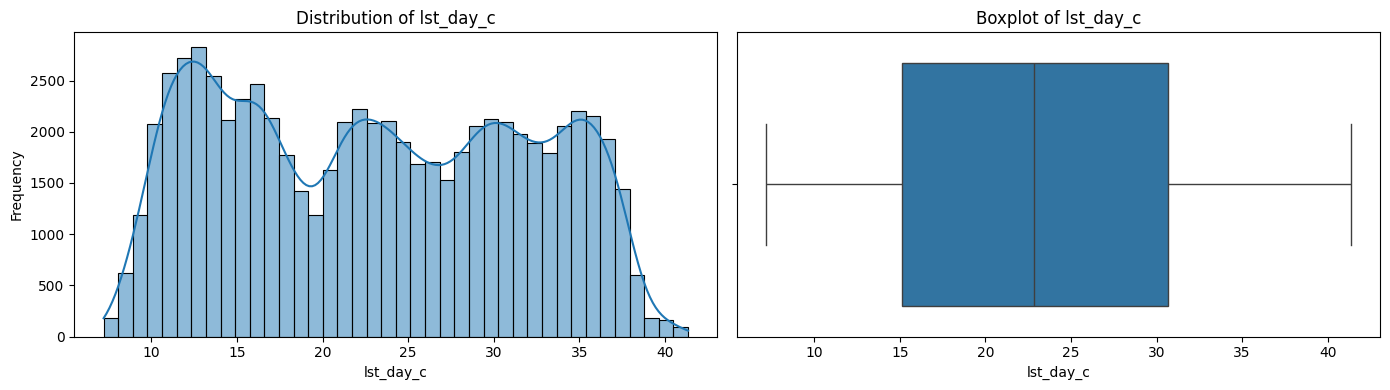

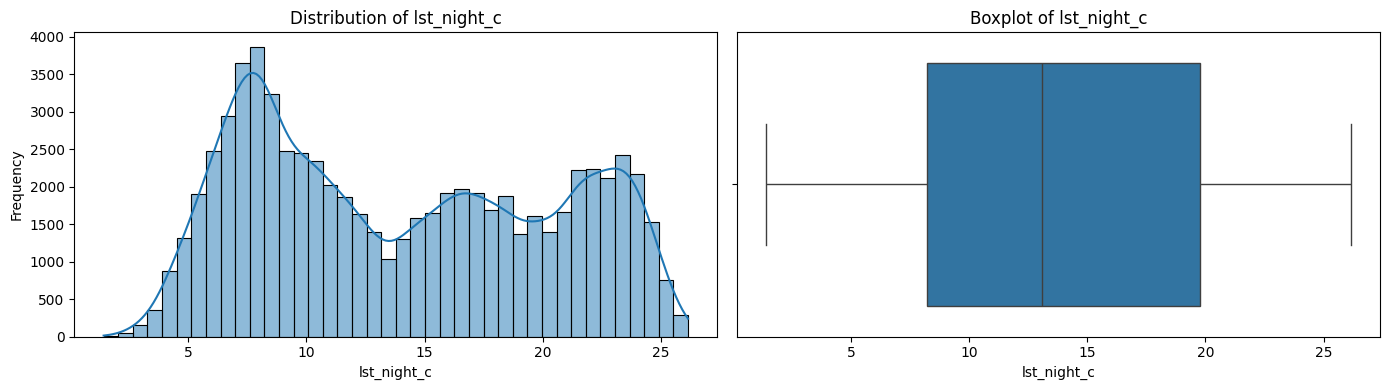

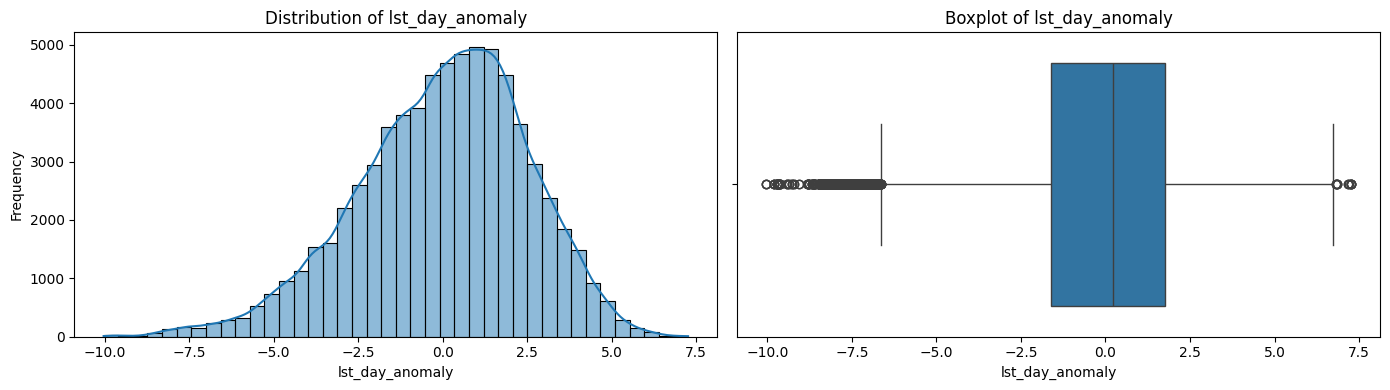

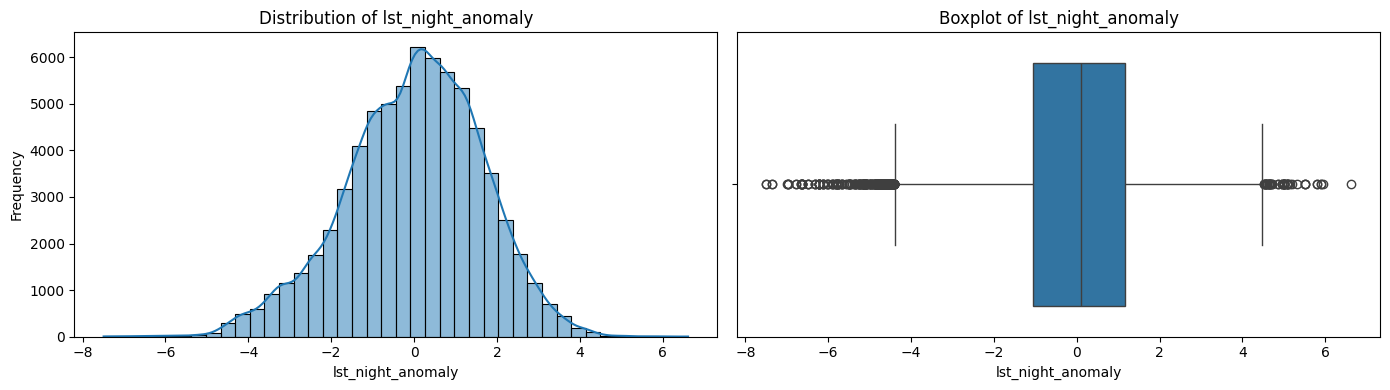

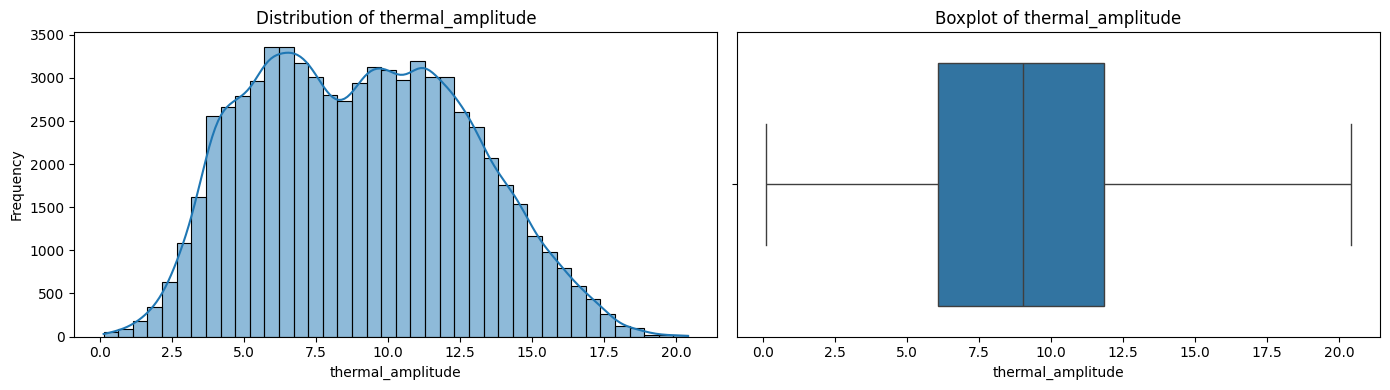

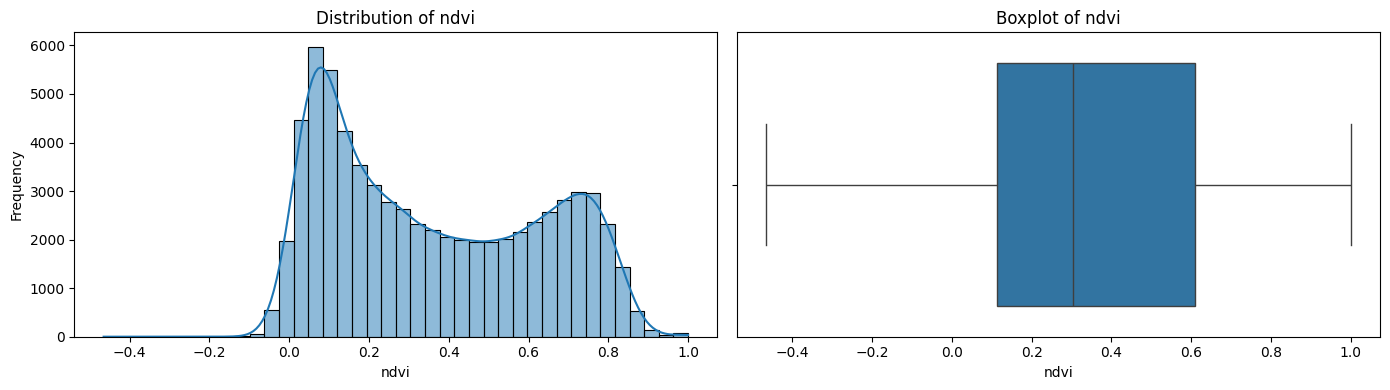

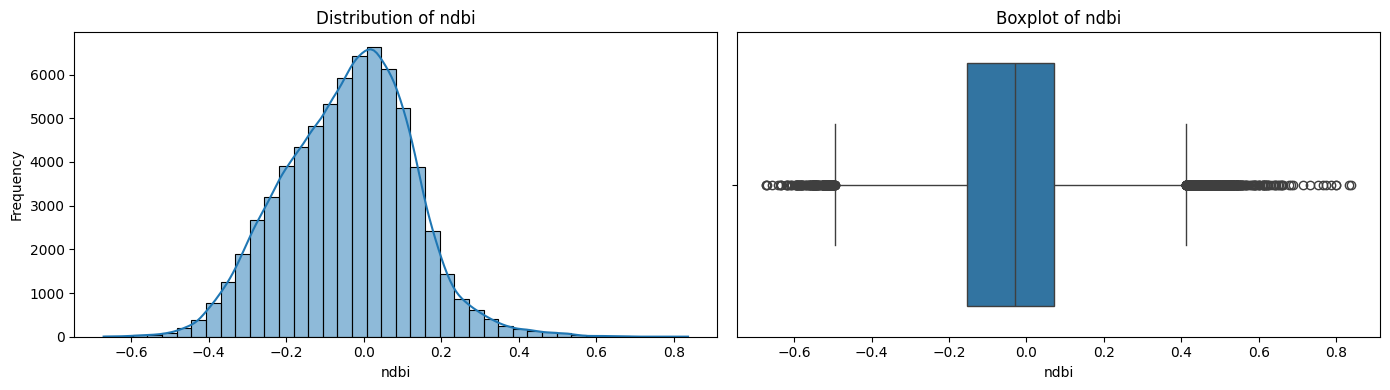

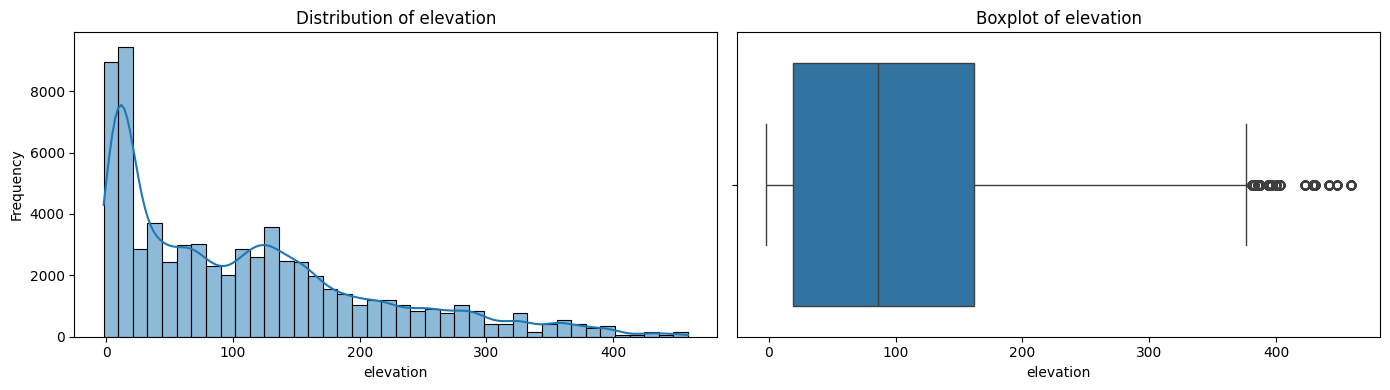

In [20]:
# ============================================================
# NUMERICAL VARIABLES DISTRIBUTION
# ============================================================

# Visualizamos la distribución y posibles outliers de las variables principales.

cols_num = [
    'lst_day_c',
    'lst_night_c',
    'lst_day_anomaly',
    'lst_night_anomaly',
    'thermal_amplitude',
    'ndvi',
    'ndbi',
    'elevation'
]

for col in cols_num:

    fig, axes = plt.subplots(
        nrows=1,
        ncols=2,
        figsize=(14, 4)
    )

    # Histograma
    sns.histplot(
        df_bcn[col],
        bins=40,
        kde=True,
        ax=axes[0]
    )

    axes[0].set_title(f'Distribution of {col}')
    axes[0].set_xlabel(col)
    axes[0].set_ylabel('Frequency')

    # Boxplot
    sns.boxplot(
        x=df_bcn[col],
        ax=axes[1]
    )

    axes[1].set_title(f'Boxplot of {col}')
    axes[1].set_xlabel(col)

    plt.tight_layout()
    plt.show()

<div style="background-color:#fff3cd; padding:20px; border-left:8px solid #ffcc00; border-radius:8px; color:#1b1b1b;">

### **Observación** 

Las variables de temperatura diurna y nocturna muestran distribuciones multimodales, lo que sugiere diferencias estacionales y espaciales dentro del dataset.

Las anomalías térmicas presentan distribuciones aproximadamente centradas en 0 y con una forma cercana a la normal, indicando que las desviaciones térmicas fueron correctamente calculadas respecto a la media mensual.

La amplitud térmica muestra una concentración principal en valores intermedios, mientras que índices espectrales como NDVI y NDBI reflejan distintos tipos de cobertura urbana y vegetación presentes en Barcelona.

Además, los boxplots no evidencian una presencia significativa de outliers extremos, lo que sugiere una buena calidad general de los datos para el modelado.

</div>

<div style="background-color:#d6eaff; border-left:6px solid #4a90e2; padding:15px; border-radius:8px; color:#1b1b1b;">

### **Análisis univariable de variables categóricas**

</div>

In [21]:
# ============================================================
# CATEGORICAL VARIABLES SUMMARY
# ============================================================

# Revisamos las variables categóricas y sus valores únicos.

cat_vars = [
    'season',
    'uhi_risk'
]

cat_summary = pd.DataFrame({

    "variable": cat_vars,

    "n_unique_values": [
        df_bcn[col].nunique() for col in cat_vars
    ],

    "values": [
        ", ".join(map(str, df_bcn[col].dropna().unique()))
        for col in cat_vars
    ]
})

cat_summary

,variable,n_unique_values,values
0,season,4,"autumn, winter, summer, spring"
1,uhi_risk,2,"0, 1"


In [22]:
df_bcn['uhi_risk'].value_counts()

uhi_risk
1    36621
0    33062
Name: count, dtype: int64

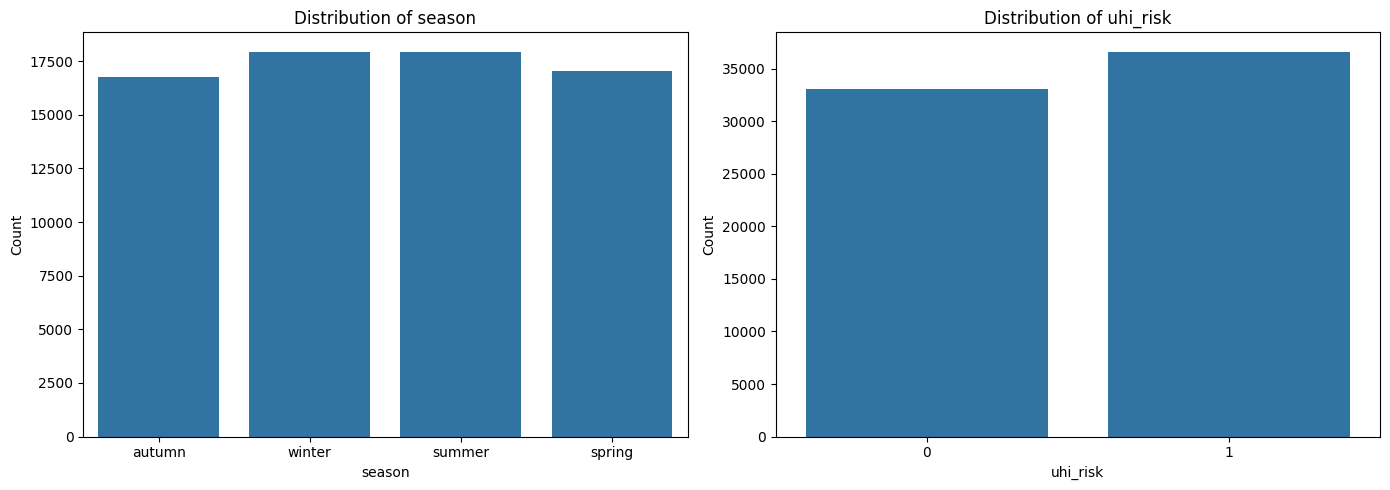

In [23]:
# ============================================================
# CATEGORICAL VARIABLES DISTRIBUTION
# ============================================================

# Visualizamos la distribución de las variables categóricas principales.

cat_cols = [
    'season',
    'uhi_risk'
]

fig, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(14, 5)
)

axes = axes.flatten()

for i, col in enumerate(cat_cols):

    sns.countplot(
        data=df_bcn,
        x=col,
        ax=axes[i]
    )

    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')

plt.tight_layout()
plt.show()

<div style="background-color:#fff3cd; padding:20px; border-left:8px solid #ffcc00; border-radius:8px; color:#1b1b1b;">

### **Observación**

Las estaciones del año presentan una distribución muy equilibrada, lo que indica que el dataset mantiene una representación temporal consistente a lo largo del período analizado.

La variable objetivo `uhi_risk` también quedó balanceada entre las categorías *low*, *medium* y *high*, debido al uso de cuantiles para su construcción. Esto es favorable para el entrenamiento de modelos de clasificación, ya que evita sesgos hacia una clase dominante.

</div>

<div style="background-color:#d6eaff; border-left:6px solid #4a90e2; padding:15px; border-radius:8px; color:#1b1b1b;">

### **variables numericas vs uhi_risk**

</div>

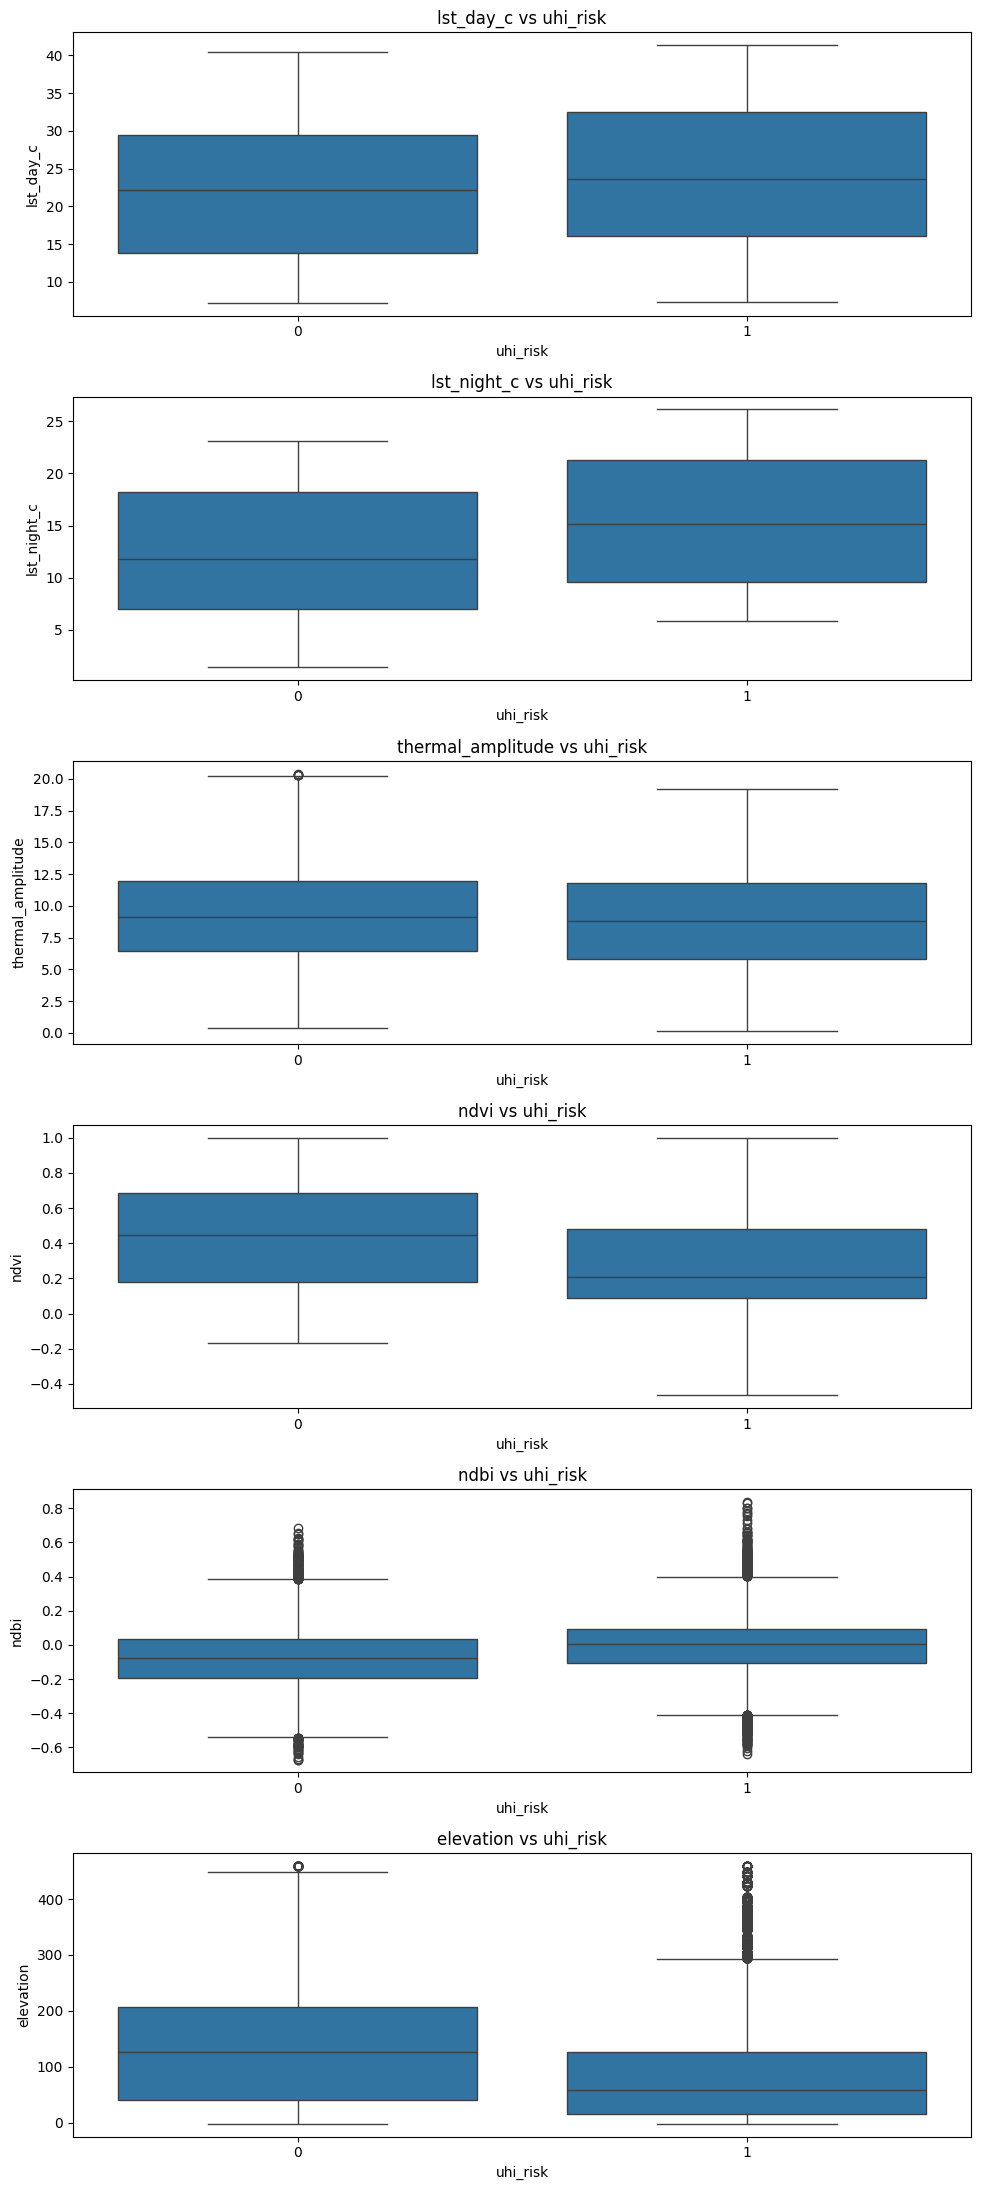

In [24]:
# ============================================================
# NUMERICAL VARIABLES VS UHI RISK
# ============================================================

# Analizamos cómo cambian las variables numéricas según el nivel de riesgo UHI.

num_vars = [
    'lst_day_c',
    'lst_night_c',
    'thermal_amplitude',
    'ndvi',
    'ndbi',
    'elevation'
]

fig, axes = plt.subplots(len(num_vars), 1, figsize=(10, 22))

for i, col in enumerate(num_vars):

    sns.boxplot(
        data=df_bcn,
        x='uhi_risk',
        y=col,
        ax=axes[i]
    )

    axes[i].set_title(f'{col} vs uhi_risk')

plt.tight_layout()
plt.show()

<div style="background-color:#fff3cd; padding:20px; border-left:8px solid #ffcc00; border-radius:8px; color:#1b1b1b;">

### **Observación variables numericas vs uhi_risk**

Las variables relacionadas con temperatura nocturna (`lst_night_c`) y cobertura (`ndvi`) urbana muestran una relación más clara con el riesgo UHI.

En particular, `lst_night_c` aumenta progresivamente entre las categorías low, medium y high, mientras que `ndvi` presenta una relación inversa, indicando menor vegetación en zonas de mayor riesgo térmico.

Por otro lado, variables como `lst_day_c` y `thermal_amplitude` muestran distribuciones más solapadas entre categorías, lo que sugiere una menor capacidad discriminatoria individual respecto al riesgo UHI.

Estos resultados refuerzan la decisión de construir la variable objetivo utilizando la anomalía térmica nocturna como principal indicador del fenómeno Urban Heat Island.

</div>

<div style="background-color:#d6eaff; border-left:6px solid #4a90e2; padding:15px; border-radius:8px; color:#1b1b1b;">

### **variables categoricas vs uhi_risk**

</div>

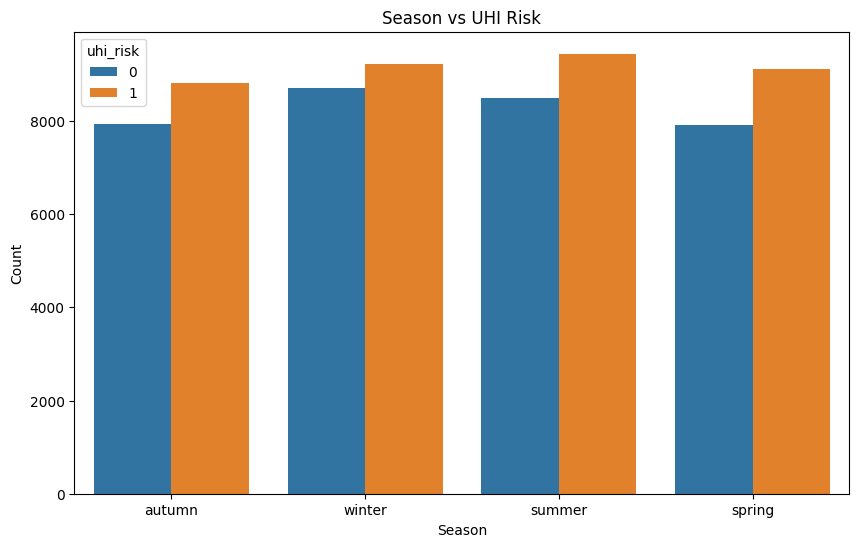

In [25]:
# ============================================================
# CATEGORICAL VARIABLES VS UHI RISK
# ============================================================

# Analizamos cómo se distribuye el riesgo UHI según la estación del año.

plt.figure(figsize=(10, 6))

sns.countplot(
    data=df_bcn,
    x='season',
    hue='uhi_risk'
)

plt.title('Season vs UHI Risk')
plt.xlabel('Season')
plt.ylabel('Count')

plt.show()

<div style="background-color:#fff3cd; padding:20px; border-left:8px solid #ffcc00; border-radius:8px; color:#1b1b1b;">

### **Observación variable categoricas vs uhi_risk**

La distribución del riesgo UHI varía según la estación del año. 

Aunque podría esperarse una mayor concentración de riesgo alto en verano, los resultados muestran una distribución relativamente equilibrada, mientras que primavera presenta una mayor cantidad de registros clasificados como `high`.

Esto sugiere que el riesgo UHI no depende únicamente de temperaturas elevadas, sino también de las diferencias térmicas relativas dentro de cada período analizado.

</div>

<div style="background-color:#fff3cd; padding:20px; border-left:8px solid #ffcc00; border-radius:8px; color:#1b1b1b;">

### **Matriz de correlación**

Para el análisis de correlación se seleccionan únicamente las variables térmicas e índices espectrales más relevantes del dataset, evitando incluir identificadores, coordenadas o variables redundantes que podrían añadir ruido visual al mapa de correlación.

El objetivo es centrarse en aquellas variables con mayor interés climático y urbano para el estudio del fenómeno Urban Heat Island (UHI), facilitando la identificación de relaciones entre temperaturas, anomalías térmicas, vegetación y superficie urbanizada.

Además, la variable objetivo `uhi_risk` se codifica temporalmente a formato numérico (`low=0`, `medium=1`, `high=2`) con el único propósito de calcular correlaciones y analizar qué variables presentan una mayor relación con el nivel de riesgo UHI.

</div>

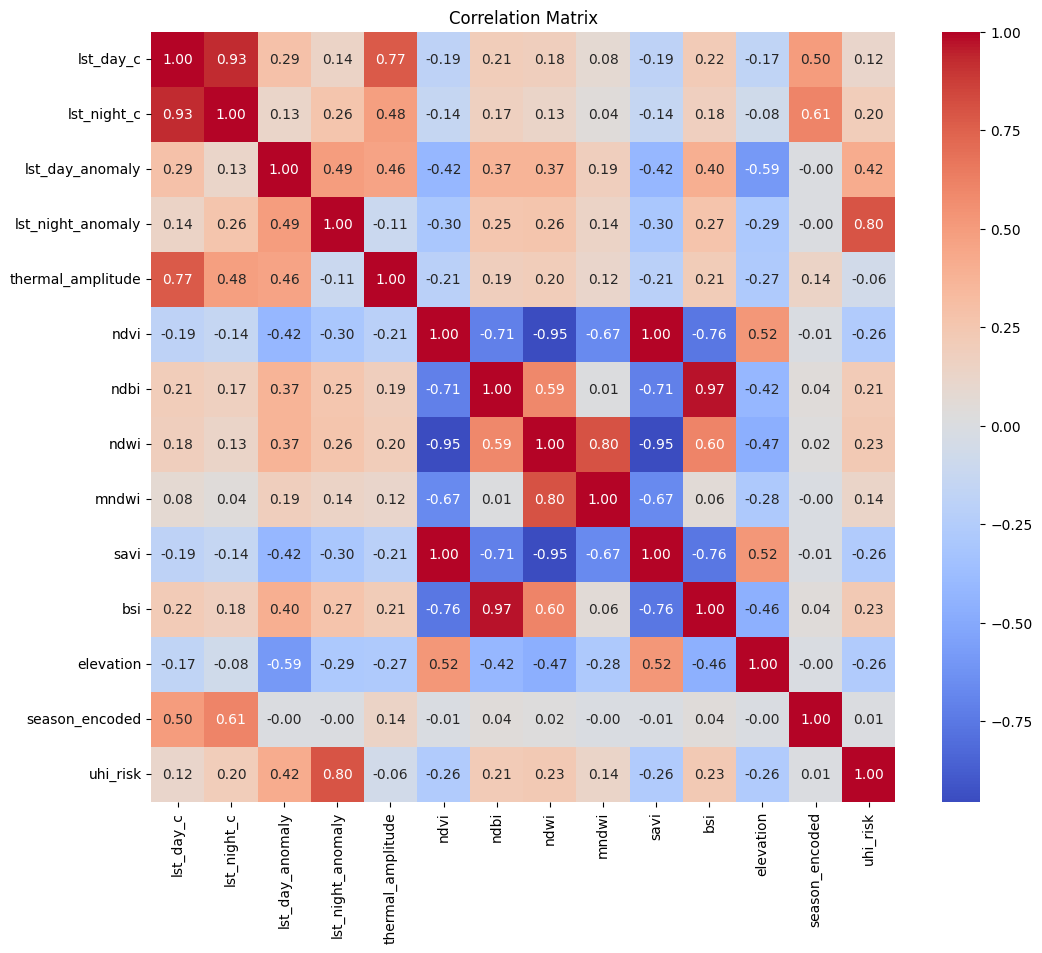

In [26]:
# ============================================================
# CORRELATION MATRIX
# ============================================================

# Codificamos temporalmente las variables categóricas para analizar correlaciones.
# - season se codifica con ordinal encoding según orden climático.
# - uhi_risk ya es binaria (0 = no risk, 1 = risk), no requiere codificación adicional.

df_corr = df_bcn.copy()

df_corr['season_encoded'] = df_corr['season'].map({
    'winter': 0,
    'spring': 1,
    'summer': 2,
    'autumn': 3
})

# Seleccionamos variables relevantes para el análisis de correlación.

corr_vars = [
    'lst_day_c',
    'lst_night_c',
    'lst_day_anomaly',
    'lst_night_anomaly',
    'thermal_amplitude',
    'ndvi',
    'ndbi',
    'ndwi',
    'mndwi',
    'savi',
    'bsi',
    'elevation',
    'season_encoded',
    'uhi_risk'
]

# Calculamos matriz de correlación.

corr_matrix = df_corr[corr_vars].corr()

# Visualizamos el mapa de correlación.

plt.figure(figsize=(12, 10))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Matrix')

plt.show()

<div style="background-color:#fff3cd; padding:20px; border-left:8px solid #ffcc00; border-radius:8px; color:#1b1b1b;">

### **Variables más relevantes respecto a `uhi_risk`**

| Variable | Correlación con `uhi_risk_encoded` | Interpretación |
|---|---|---|
| `lst_night_c_anomaly` | **0.89** | Variable más importante. Representa directamente la retención anómala de calor nocturno asociada al fenómeno UHI. |
| `lst_day_c_anomaly` | **0.45** | El comportamiento térmico diurno también influye en el riesgo UHI. |
| `ndvi` | **-0.30** | Más vegetación → menor riesgo UHI. |
| `savi` | **-0.30** | Refuerza la misma idea observada en NDVI. |
| `ndwi` | **0.26** | Puede estar capturando humedad o determinadas superficies urbanas. |
| `bsi` | **0.26** | Más suelo construido/desnudo → mayor riesgo UHI. |
| `lst_night_c` | **0.22** | Temperaturas nocturnas elevadas → mayor persistencia del calor urbano. |

</div>

<div style="background-color:#fff3cd; padding:20px; border-left:8px solid #ffcc00; border-radius:8px; color:#1b1b1b;">

### **Posibles variables redundantes detectadas**

La matriz de correlación también permite identificar variables con correlaciones extremadamente altas entre sí, lo que puede indicar redundancia de información. Este análisis será importante durante la fase de modelado para reducir multicolinealidad, simplificar el conjunto de features y mejorar la interpretabilidad del modelo.

| Variables | Correlación | Motivo de posible redundancia |
|---|---|---|
| `ndvi` ↔ `savi` | **1.00** | Ambas variables representan cobertura vegetal y aportan prácticamente la misma información. |
| `ndvi` ↔ `ndwi` | **-0.95** | Aunque representan fenómenos distintos (vegetación y humedad), muestran comportamientos muy similares en el dataset. |
| `lst_day_c` ↔ `lst_night_c` | **0.93** | Las temperaturas diurnas y nocturnas tienden a evolucionar conjuntamente en muchas zonas urbanas. |
| `ndbi` ↔ `bsi` | **0.97** | Ambas variables están relacionadas con superficies urbanas o suelo desnudo, mostrando patrones muy similares. |

<br>

Aun así, una correlación alta no implica automáticamente que una variable deba eliminarse. También es importante considerar si las variables representan fenómenos físicos distintos y el impacto real que tienen sobre el rendimiento del modelo.

</div>

<div style="background-color:#d6eaff; border-left:6px solid #4a90e2; padding:15px; border-radius:8px; color:#1b1b1b;">

### **Ingenieria de caracteristicas**

</div>

In [ ]:
# ============================================================
# FEATURE SELECTION
# ============================================================

# Eliminamos variables que no aportan valor al modelado:
# - point_id: identificador único sin significado físico.
# - city: contiene un único valor ('Barcelona') y no aporta variabilidad.
# - date: ya fue descompuesta en variables temporales más útiles como month, year.

cols_drop = ['point_id', 'date']

df_bcn = df_bcn.drop(columns=cols_drop)

# Verificamos las columnas restantes
df_bcn.columns.tolist()

['latitude',
 'longitude',
 'elevation',
 'month',
 'year',
 'bsi',
 'mndwi',
 'nbr',
 'ndbi',
 'ndmi',
 'ndvi',
 'ndwi',
 'nir',
 'savi',
 'swir1',
 'swir2',
 'lst_day_c',
 'lst_night_c',
 'lst_day_anomaly',
 'lst_night_anomaly',
 'thermal_amplitude',
 'season',
 'uhi_risk']

In [48]:
# ============================================================
# REMOVING REDUNDANT VARIABLES
# ============================================================

# Eliminamos variables redundantes o auxiliares antes del modelado:
# - savi: altamente correlacionada con ndvi (correlación ≈ 1.00).
# - bsi: altamente correlacionada con ndbi (correlación ≈ 0.97).
# - uhi_risk_encoded: solo fue creada para el análisis de correlación.

redundant_features = [
    'savi',
    'bsi',
    'uhi_risk_encoded',
    'lst_night_anomaly',
    'lst_night_c',
    'lst_day_anomaly',
    'lst_day_c',
    'thermal_amplitude',
    'month',
    'year'
]

df_bcn = df_bcn.drop(
    columns=[c for c in redundant_features if c in df_bcn.columns]
)

df_bcn.columns.tolist()

['latitude',
 'longitude',
 'elevation',
 'mndwi',
 'nbr',
 'ndbi',
 'ndmi',
 'ndvi',
 'ndwi',
 'nir',
 'swir1',
 'swir2',
 'season',
 'uhi_risk']

In [50]:
# ============================================================
# SAVE CLEAN DATASET FOR MODELING
# ============================================================

# Guardamos el dataset procesado tras el EDA y feature engineering
# para utilizarlo posteriormente en el notebook de modelado.

df_bcn.to_csv('../data/processed/dataset_modeling.csv', index=False)